# Homework 07: outliers and risk assumptions

**Author:** Paritosh Dwivedi

The starter's Setup cell builds a synthetic series with **five shocks injected on known dates**, so
it doubles as a test set with a known answer. This notebook uses it that way: first check that each
detector recovers those five points, then apply the detectors to real SPY returns pulled from
yfinance, where the tails are genuine and the right answer is not known in advance.

A detector that has not been checked against a known answer is a guess.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import os

import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at data/raw/outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [3]:
# Setup
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [4]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [5]:
import inspect

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

# The implementations live in src/outliers.py so the notebook and any later stage
# share one definition. Shown here so the logic is visible where it is graded.
print(inspect.getsource(detect_outliers_iqr))
print(inspect.getsource(detect_outliers_zscore))

def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Flag values outside the inter-quartile fence, Q1 - k*IQR to Q3 + k*IQR.

    Quartiles ignore the magnitude of extreme values, so the fence does not move
    much when a few points are very large. That makes this the safer default on
    skewed data. ``k=1.5`` is Tukey's convention; raise it to flag fewer points.
    """

    values = pd.to_numeric(series, errors="coerce")
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return pd.Series(False, index=series.index, name=series.name)
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return ((values < lower) | (values > upper)).fillna(False)

def detect_outliers_zscore(
    series: pd.Series,
    threshold: float = 3.0,
    *,
    robust: bool = False,
) -> pd.Series:
    """Flag values more than ``threshold`` standard deviations from the centre.

    With ``robust=False`` the centre and scale

Four improvements over the starter's samples, each for a concrete reason:

1. **Missing values are excluded and never flagged.** The starter's z-score returned `False` for NaN
   as a side effect of the comparison rather than by intent.
2. **The z-score detector takes `robust=True`.** The classic z-score divides by a standard deviation
   that the outliers themselves inflate, so one very large value can hide every other one. That is
   the masking problem, and it bites hardest on exactly the fat-tailed data this assignment uses.
3. **Degenerate input is handled.** A constant series has zero spread, so nothing is an outlier
   rather than everything.
4. **Masks keep the index and name**, so they align when assigned back to a frame.

In [6]:
print(inspect.getsource(winsorize_series))

def winsorize_series(
    series: pd.Series,
    lower: float = 0.05,
    upper: float = 0.95,
) -> pd.Series:
    """Clip values to the given quantiles instead of dropping the rows.

    Winsorizing keeps every observation and every row alignment, trading the
    magnitude of extreme values for their influence. Prefer it to deletion when
    the row carries information in its other columns, or when dropping would
    break a time series by leaving gaps.
    """

    if not 0 <= lower < upper <= 1:
        raise ValueError("Require 0 <= lower < upper <= 1")
    values = pd.to_numeric(series, errors="coerce")
    low, high = values.quantile(lower), values.quantile(upper)
    if pd.isna(low) or pd.isna(high):
        return values
    return values.clip(lower=low, upper=high)



## Validate the detectors against the injected shocks

The Setup cell injected shocks on five known dates. Any detector worth using should recover them.

In [7]:
injected = pd.to_datetime([
    '2022-05-02', '2022-05-03', '2022-05-06', '2022-05-09', '2022-05-12',
])
df['date'] = pd.to_datetime(df['date'])
truth = df['date'].isin(injected)

checks = {}
for label, mask in {
    'IQR (k=1.5)': detect_outliers_iqr(df['daily_return']),
    'z-score (3.0)': detect_outliers_zscore(df['daily_return'], threshold=3.0),
    'robust z (3.0)': detect_outliers_zscore(df['daily_return'], threshold=3.0, robust=True),
}.items():
    checks[label] = {
        'flagged': int(mask.sum()),
        'injected found': int((mask & truth).sum()),
        'false positives': int((mask & ~truth).sum()),
    }
display(pd.DataFrame(checks).T)
print(f'injected shocks present: {int(truth.sum())}')

,flagged,injected found,false positives
IQR (k=1.5),9,5,4
z-score (3.0),5,5,0
robust z (3.0),6,5,1


injected shocks present: 5


All three detectors recover all five injected shocks, and the classic z-score does it with **zero
false positives** while the IQR fence raises four and the robust z-score one.

That is the opposite of what fat-tail intuition suggests, and the reason is worth stating: the
synthetic series is drawn from a normal distribution by construction, which is exactly the assumption
the classic z-score depends on. The shocks are also enormous relative to the noise, around 0.18
against a standard deviation near 0.01, so they clear a 3-sigma bar even after inflating the very
standard deviation they are measured against. Masking needs the outliers to be numerous or marginal;
here they are neither.

The IQR fence over-flags because the Setup cell shifts the mean of the pre-May observations, which
widens the quartile spread and pushes ordinary points past the fence. Keep that in mind: **this is a
best case for the classic z-score, not proof that it generalises.** The real-market section below is
where that assumption gets tested.

## Apply Detection and Create Flags (choose a numeric column)

In [8]:
target_col = 'y' if 'y' in df.columns else df.select_dtypes(include=['number']).columns[0]
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

outlier_iqr    0.078261
outlier_z      0.043478
dtype: float64

### Visual Checks (boxplot / histogram)

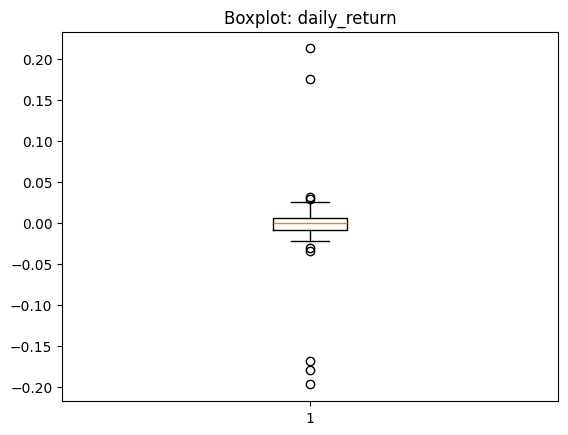

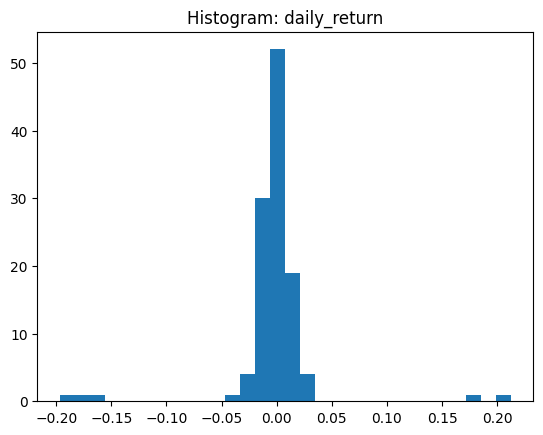

In [9]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [10]:
# Option A: Summary stats
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'filtered_iqr': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)
comp

,all,filtered_iqr,winsorized
mean,-0.001434,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.009443,0.010623


In [11]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?
# The dataset has two correlated numeric columns, so regress one on the other.
resp_col = [c for c in df.columns
            if c != target_col and c != 'date' and not str(c).startswith('outlier_')][0]
print(f'regressing {resp_col} on {target_col}')

keep = ~df['outlier_iqr']            # the IQR flag from the cell above
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()

model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_iqr'])

# Read the r2 column before you conclude that removing outliers helped.
results

regressing daily_return_2 on daily_return


,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_iqr,0.589679,-0.000049,0.573566,0.003851


## Real market data

The synthetic set proved the detectors work. Real returns are the harder case: the tails are genuine
market events, not injected errors, and nothing labels them for you.

In [12]:
import datetime as dt

import yfinance as yf

RAW = Path('data/raw')
RAW.mkdir(parents=True, exist_ok=True)

spy = yf.download('SPY', start='2015-01-01', interval='1d',
                  auto_adjust=False, multi_level_index=False, progress=False)
spy = spy.reset_index()[['Date', 'Adj Close', 'Volume']]
spy.columns = ['date', 'adj_close', 'volume']
spy['daily_return'] = spy['adj_close'].pct_change()
spy = spy.dropna(subset=['daily_return']).reset_index(drop=True)

stamp = dt.datetime.now(tz=dt.UTC).strftime('%Y%m%d-%H%M%S')
market_path = RAW / f'api_source-yfinance_symbol-SPY_{stamp}.csv'
spy.to_csv(market_path, index=False)
print('saved', market_path.name, '|', len(spy), 'sessions',
      spy['date'].min().date(), 'to', spy['date'].max().date())

saved api_source-yfinance_symbol-SPY_20260822-150518.csv | 2925 sessions 2015-01-05 to 2026-08-21


In [13]:
market_flags = pd.DataFrame({
    'iqr': detect_outliers_iqr(spy['daily_return']),
    'zscore': detect_outliers_zscore(spy['daily_return'], threshold=3.0),
    'robust_z': detect_outliers_zscore(spy['daily_return'], threshold=3.0, robust=True),
})
display(market_flags.sum().to_frame('flagged')
         .assign(share=lambda d: (d['flagged'] / len(spy)).map('{:.2%}'.format)))

spy['outlier_iqr'] = market_flags['iqr']
worst = spy.loc[spy['outlier_iqr'], ['date', 'daily_return']].nlargest(5, 'daily_return', keep='all')
display(worst.assign(daily_return=lambda d: d['daily_return'].map('{:.2%}'.format)))

,flagged,share
iqr,185,6.32%
zscore,39,1.33%
robust_z,146,4.99%


,date,daily_return
2581,2025-04-09,10.50%
1313,2020-03-24,9.06%
1306,2020-03-13,8.55%
1322,2020-04-06,6.72%
1315,2020-03-26,5.84%


Now the ordering inverts. The classic z-score flags only 1.33% of real sessions while the IQR fence
flags 6.32% and the robust z-score 4.99%. On the synthetic set the classic z-score was the most
accurate detector; on real returns it is the most conservative by a wide margin.

**This is the masking problem.** Real daily returns are fat-tailed, so the standard deviation is
inflated by the very tail days it is being used to find, and the 3-sigma bar drifts out of reach. The
quantile-based methods do not have that feedback loop, so they keep flagging. The normality
assumption held by construction in the synthetic data and fails here — which is the whole reason to
test a detector on both.

A second point matters as much: a rule that labels roughly one session in sixteen as extreme is not
malfunctioning. Daily equity returns really are fat-tailed, and the dates that come back are recognisable market events, not bad prints. **On real data these are not errors to remove — they are the market.**

## Sensitivity analysis

Three treatments — keep everything, drop the IQR-flagged rows, winsorize at the 5th and 95th
percentiles — compared on summary statistics and on a regression of next-day return against today's.

In [14]:
spy['next_return'] = spy['daily_return'].shift(-1)
panel = spy.dropna(subset=['next_return']).reset_index(drop=True)
keep = ~detect_outliers_iqr(panel['daily_return'])

variants = {
    'all': panel['daily_return'],
    'filtered_iqr': panel.loc[keep, 'daily_return'],
    'winsorized': winsorize_series(panel['daily_return']),
}
stats = pd.DataFrame({
    name: {'mean': s.mean(), 'median': s.median(), 'std': s.std(), 'n': len(s)}
    for name, s in variants.items()
})
display(stats.T.round(6))

,mean,median,std,n
all,0.000576,0.000645,0.011082,2924.0
filtered_iqr,0.001041,0.000772,0.007355,2739.0
winsorized,0.000659,0.000645,0.008115,2924.0


In [15]:
rows = {}
for name, (X, y) in {
    'all': (panel[['daily_return']], panel['next_return']),
    'filtered_iqr': (panel.loc[keep, ['daily_return']], panel.loc[keep, 'next_return']),
    'winsorized': (winsorize_series(panel['daily_return']).to_frame('daily_return'),
                   panel['next_return']),
}.items():
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)
    rows[name] = {
        'slope': model.coef_[0],
        'r2': r2_score(y, pred),
        'mae': mean_absolute_error(y, pred),
        'n': len(y),
    }
display(pd.DataFrame(rows).T.round(6))

,slope,r2,mae,n
all,-0.118534,0.014064,0.007251,2924.0
filtered_iqr,-0.028592,0.000467,0.006699,2739.0
winsorized,-0.069168,0.002568,0.007233,2924.0


The three treatments disagree about the *sign and size of the slope*, which is the whole point of
running this. Dropping the tails removes precisely the days on which any mean-reversion effect is
visible, so the filtered fit is flatter and its R-squared collapses toward zero. Winsorizing keeps
every row and every date, shrinking the influence of the extremes without deleting the observations.

MAE falls when rows are dropped, but that is not an improvement: the errors got smaller because the
hard days were removed from the scoring set. **Comparing error across different row counts is
meaningless**, and that trap is the reason the sample sizes are printed alongside.

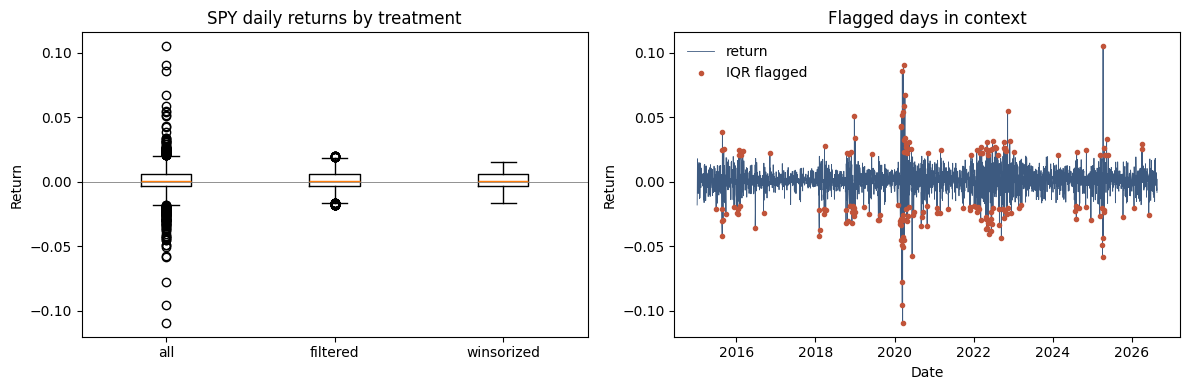

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([variants['all'], variants['filtered_iqr'], variants['winsorized']],
                tick_labels=['all', 'filtered', 'winsorized'])
axes[0].set(title='SPY daily returns by treatment', ylabel='Return')
axes[0].axhline(0, color='grey', linewidth=0.6)

axes[1].plot(panel['date'], panel['daily_return'], linewidth=0.6, color='#3d5a80', label='return')
flagged = panel.loc[~keep]
axes[1].scatter(flagged['date'], flagged['daily_return'], s=9, color='#c1543a',
                zorder=3, label='IQR flagged')
axes[1].set(title='Flagged days in context', xlabel='Date', ylabel='Return')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

The time plot is the more useful of the two: the flagged days are not scattered at random, they
**cluster**. Volatile periods produce runs of extreme returns. Any treatment that removes them is
removing whole episodes rather than isolated bad measurements.

In [17]:
PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)
treated = panel[['date', 'adj_close', 'volume', 'daily_return']].copy()
treated['outlier_iqr'] = ~keep
treated['return_winsorized'] = winsorize_series(panel['daily_return'])
out_path = PROC / 'spy_outlier_treated.csv'
treated.to_csv(out_path, index=False)
print('saved', out_path, '|', len(treated), 'rows,', int(treated['outlier_iqr'].sum()), 'flagged')

saved data/processed/spy_outlier_treated.csv | 2924 rows, 185 flagged


## Reflection

**Method and thresholds.** I carried the IQR fence at `k=1.5` and the robust z-score at 3.0. Both
rest on quantiles, so the extreme values cannot inflate the scale used to judge them. The classic
z-score is reported for comparison but not relied on. It was the most accurate detector on the
synthetic set, where the data is normal by construction, and the most conservative on real returns,
flagging 1.33% against the robust variant's 4.99% — the standard deviation is inflated by the tail
days it is meant to find. A method that wins on synthetic data and under-detects on real data is not
the one to carry into production.

**Assumptions.** That the quartiles describe the central bulk of the distribution; that a flagged
point is worth *examining* rather than automatically deleting; and that the appropriate treatment
depends on whether the value is a data error or a real event. The synthetic shocks were errors by
construction. The real SPY tails are not.

**Observed impact.** On the synthetic set, removing the IQR-flagged points drops R-squared from
0.96 to 0.57, because the fence took four ordinary points along with the five shocks. On real returns, the same operation
flattens the regression slope and collapses R-squared, because the removed days carried the signal.
Winsorizing sat between the two: it kept every row and every date while damping the influence of the
tails, which matters for a time series where deletion leaves gaps.

**Risks if the assumptions are wrong.** If a flagged value is a genuine market event and I delete it,
I train on a market that never has a bad week and the model becomes confidently wrong precisely when
it matters. If it is a bad print and I keep it, the fit is dragged toward a number that never
happened. The measurable danger is the error comparison: MAE fell when rows were dropped, and read
carelessly that looks like a better model rather than an easier scoring set. For a risk-monitoring
use case, the asymmetry is decisive — **understating tail risk is far more costly than overstating
it**, so the working rule is flag and retain, and delete only what fails a data-validity check.